### Project 2 Report
Xiaohe Jin Oct-24-2025

# Introduction:
The research motivation of the study *(1)* is to understand how the identified type 1 diabetes (T1D) gene TYK2 contribute to the b-cells development and its response type-Ι interferon (IFNa). To address this, the authors generated TYK2 knockout (KO) human induced pluripotent stem cells (hiPSCs) and differentiated them into pancreatic endocrine cells, providing a model system to explore the molecular consequences of TYK2 loss. The study employed advanced bioinformatic techniques, including ultra-deep bulk RNA sequencing for transcriptomic profiling, differential expression analysis, and Reactome pathway enrichment, to highlight changes in gene regulation and pathway activity. Furthermore, single-cell RNA sequencing was used to capture cell subtype-specific effects of TYK2 knockout. These multi-omics approaches enabled the authors to reveal key mechanisms by which TYK2 influences β-cell maturation and immune responses, supporting the potential of TYK2 inhibition as a therapeutic strategy for T1D.

### Methods:
Raw RNA-seq data from S5-stage wild type (WT) and TYK2 knockout (KO) human induced pluripotent stem cell (hiPSC) samples were processed using a modular workflow implemented in Nextflow (v25.04.6) *(2)*. All bioinformatics software tools were executed within Docker containers *(3)* specified for each process, ensuring computational reproducibility, portability, and consistency across different computing environments.
#### Quality Control 
FastQC (v0.12.1) (https://github.com/s-andrews/FastQC) was served as the initial quality control for all sequencing reads in paired, which were organized into input channels using operator Channel.fromFilePairs and filtered with default settings. All FastQC reports were subsequently aggregated with MultiQC (v 1.25) *(4)*. A single overview containing the quality metrics for the filtered sequencing reads across all samples and alignments conducted by STAR aligner *(5)* was created by MultiQC with default settings.
#### Gene Identifier Mapping and Genome Index Generation
To ensure consistent and interpretable downstream analysis, our genes in the ensembl gene id format were converted to gene names by a custom Python script (Biopython, v1.84). This script parsed the GTF file corresponding to the human reference genome (GRCh38). Afterwards, the reference genome was indexed using STAR command “--runMode genomeGenerate”, with both the genome FASTA and GTF files as input.  
#### Read Alignment and Gene-Level Quantification
Paired-end reads were aligned to the indexed human reference genome using the STAR aligner (v 2.7.11b). Besides the BAM alignment files of each sample, another output of STAR aligner is the detailed log files (.Log.final.out), which were used to assess mapping rates and alignment quality in MultiQC. Gene-level counts were generated for each sample using VERSE (v 0.1.5) *(6)*. This gene-level count could be used as a proxy for that gene’s expression in a particular sample. In VERSE, we generated a single count for every gene representing the sum of the union of all alignments falling into every exon annotated to that gene. Notice, ‘-S’ symbol was specified since the input file is not sorted by read name. Each VERSE output was named according to its corresponding sample. All output files from VERSE were then concatenated into a single counts matrix using a custom Python script, yielding a matrix with genes as rows and samples as columns for downstream statistical analysis.
#### Pre-Filtering of Counts Matrix
Gene-level counts from the concatenated matrix were filtered to remove genes that are likely uninformative for differential expression analysis. For this analysis, we removed genes with low expression levels from the analysis (<50 reads across all samples). A bar plot comparing the gene counts before and after filtration was created. 
#### Differential Expression Analysis
Differential expression analysis was performed using the DESeq2 package in R *(7)*, comparing WT and TYK2 KO gene counts at the S5 stage. In detail, the filtered count matrix was first supplied along with the colData, which annotated sample conditions (exp for TYK2 KO samples, and control for WT) before running DEseq2. According to the original publication, a threshold of padj (p-value) < 0.01 was applied to rank the top 10 differentially expressed genes, which were then performed for a functional enrichment analysis. Moreover, a volcano plot for S5 differentially expressed genes was created, representing the genes significantly downregulated and upregulated genes according to the log2FoldChange values. 
#### Gene Set Enrichment Analysis (GSEA) and Functional Enrichment Analysis
For GSEA, genes were ranked according to log2FoldChange values from the differential expression results and then submitted to the fgsea package in R *(8)* using the C2 canonical pathways from the MSigDB *(9)*. FGSEA was run with default parameters, and top significant pathways were visualized using a bar plot. 
In parallel, significantly differentially expressed genes (padj < 0.01) were subjected to gene ontology and pathway enrichment analysis using ENRICHR *(10)*. 
#### RNA-seq Quality Control
To assess global patterns and sample quality, normalized counts were produced using the variance-stabilizing transformation (vst) in DESeq2. Principal component analysis (PCA) was performed on the normalized count matrix, and sample groupings were visualized in a biplot colored by experimental condition. A sample-to-sample distance matrix was also calculated and displayed as a heatmap, enabling assessment of clustering and outliers. 

### Results
#### Quality Control Evaluation
FASTQC and STAR Aligner outputs for all six RNA-seq samples were summarized using MultiQC. According to the general statistics section, reads from all samples aligned well to the reference genome (GRCh38), with 95.8–97.8% of reads mapped and 92–94% uniquely aligned. The total read counts ranged from approximately 84.5 million to 118.9 million per sample. Mismatch rates for all samples were low at 0.2%, and indel rates were reported as 0.0%, with detected indel lengths <2 bp. The high alignment percentage and low mismatch rates indicate a well-prepared and high-quality RNA library with minimal sequencing errors. Moreover, GC content was consistent across samples (~48–50%), suggesting no major bias in nucleotide composition. Minor adapter contamination (≤0.02% of reads) and overrepresented sequences (<0.1%) were detected, indicating negligible contamination.
Regarding potential issues, duplicate ratios ranged from 73.6% to 76.2%. Although these values appear high, this is expected for highly expressed transcripts that are repeatedly sampled in RNA-seq libraries. The Per Base Sequence Content test from FASTQC reported relatively high z-scores (0.25–0.5), indicating that the proportions of A, T, G, and C bases vary slightly more than expected across positions in the reads.
#### Filtering the counts matrix
To improve the reliability of differential expression analysis, genes with low expression (<50 reads across all samples) were removed from the raw gene counts. As shown in the bar plot **(Figure 1)**, this filtration step reduced the number of genes from 63,241 to 20,856. Ultimately, filtration serves a dual purpose: to reduce computational burden and to remove uninformative data.

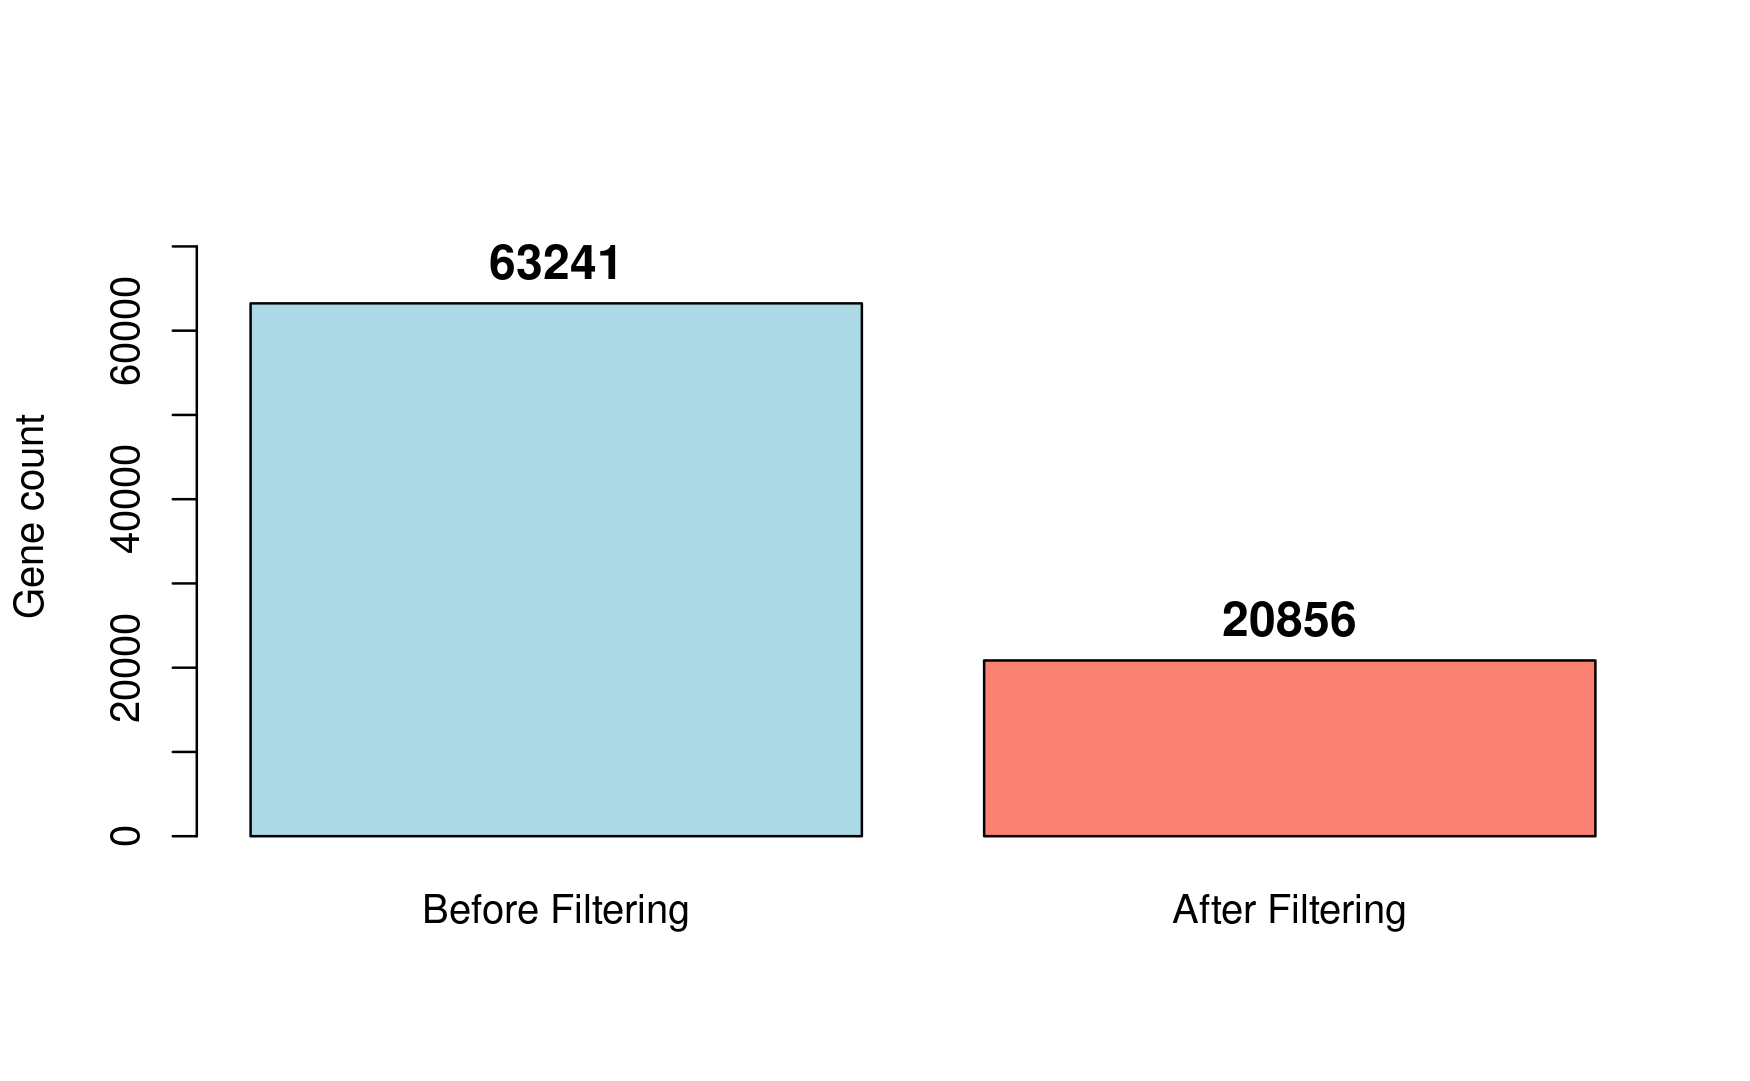
Figure 1. Bar plot of the number of genes presents before and after filtering the counts matrix for low expression. The actual counts are indicated above each bar.

#### Differential Expression Analysis
Differential gene expression analysis of TYK2 knockout (KO) versus wild-type (WT) samples at the stage S5 identified 730 significantly dysregulated genes using a stringent adjusted p-value threshold (padj < 0.01). The top 10 most significantly altered genes, ranked by padj, are presented in Table 1. This list includes profound transcriptional changes, with RPS4Y1 (log2FC = -8.77) and PNPO (log2FC = -4.16) as the most downregulated, and SLC2A14 (log2FC = 4.69) and PCDHGA10 (log2FC = 4.48) as the most upregulated. The reliability of these fold-change estimates is underscored by exceptionally low log2 fold change standard errors (lfcSE range: 0.12 – 0.28), indicating high measurement precision and a strong signal-to-noise ratio in the dataset.

Table 1. Top 10 Differentially Expressed Genes in TYK2 KO Compared with WT
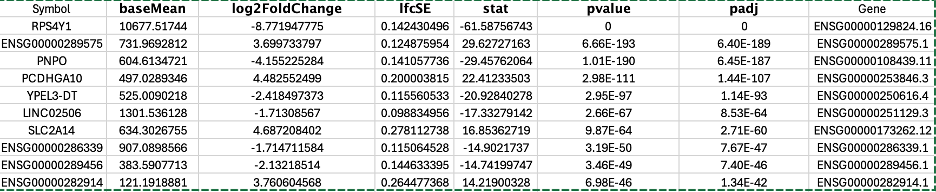

#### ENRICHR analysis
Pathway enrichment analysis was performed on the significant gene set using ENRICHR (Reactome 2024 database) (10.1186/1471-2105-14-128). The bar plot of enrichment (Figure 2) revealed several strongly enriched pathways (p-value < 1x10⁻⁸), including "Regulation of Beta-Cell Development," "TP53 Regulates Transcription of Cell Death Genes," "Regulation of Gene Expression in Endocrine-Committed (NEUROG3+) Progenitor Cells," and "Neuronal System." This enrichment pattern indicates two primary biological consequences of TYK2 knockout: first, a severe disruption of the genetic program essential for endocrine lineage commitment, and second, a concomitant dysregulation of apoptotic signaling that may impact progenitor cell survival. Overall, these findings strongly support the conclusion that TYK2 is a critical regulator of endocrine differentiation and associated cellular processes.

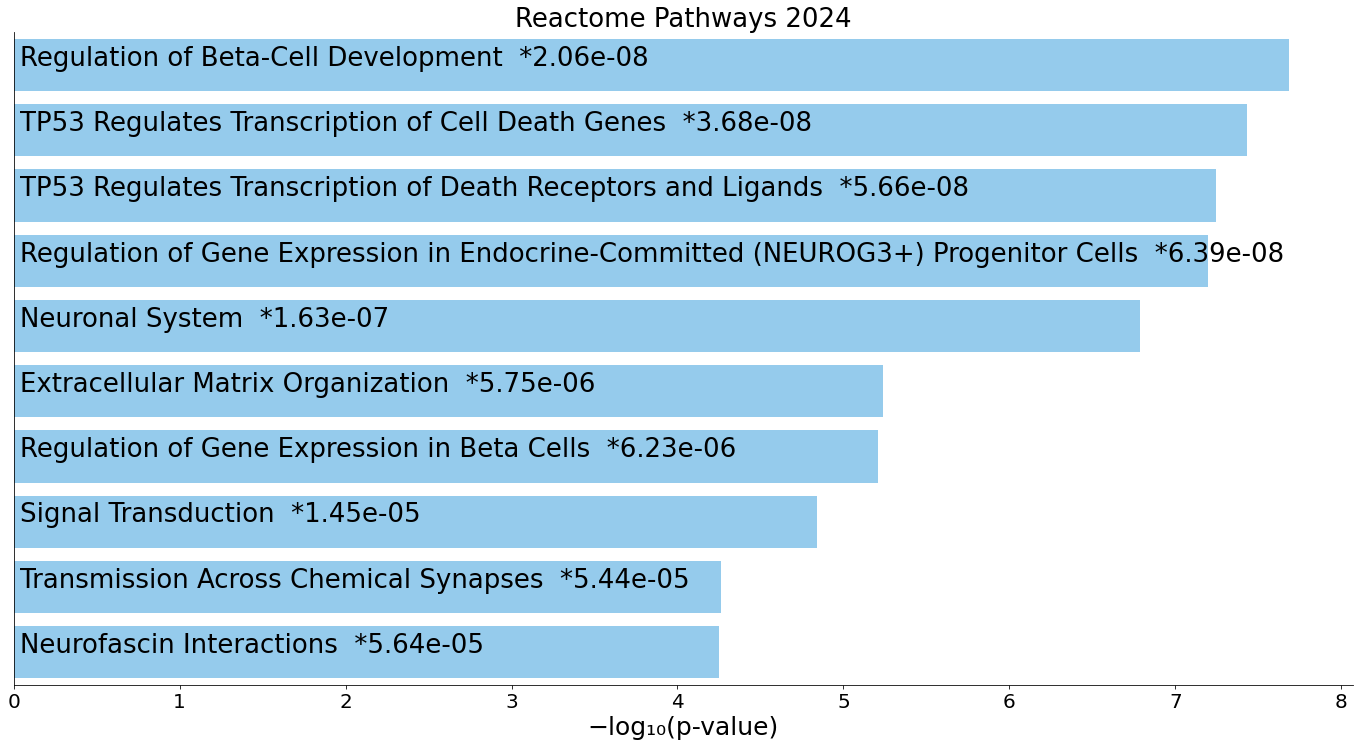
Figure 2. Pathway Enrichment with ENRICHR (Reactome 2024 database) with Top 10 Significant Genes (padj < 0.01). 

#### GSEA analysis using fgsea
Genes ranked by log2 FC were further sent to the Gene set enrichment analysis (GSEA) was performed using the fgsea package and the C2 canonical pathways MSigDB gene sets. The most significantly enriched pathways (padj < 0.05) are depicted in Figure 3. Among up-regulated pathways, 'PID_P53_DOWNSTREAM_PATHWAY', 'WP_IL18_SIGNALING', and 'REACTOME_EXTRACELLULAR_MATRIX_ORGANIZATION' were prominent, consistent with a shift in apoptotic regulation and cytokine signaling. Down-regulated pathways predominantly related to neuronal function and development, exemplified by enrichment in 'REACTOME_NEURONALSYSTEM', 'REACTOME_TRANSMISSION_ACROSS_CHEMICAL_SYNAPSES', 'REACTOME_POTASSIUM_CHANNELS', and autism spectrum disorder-associated signaling.

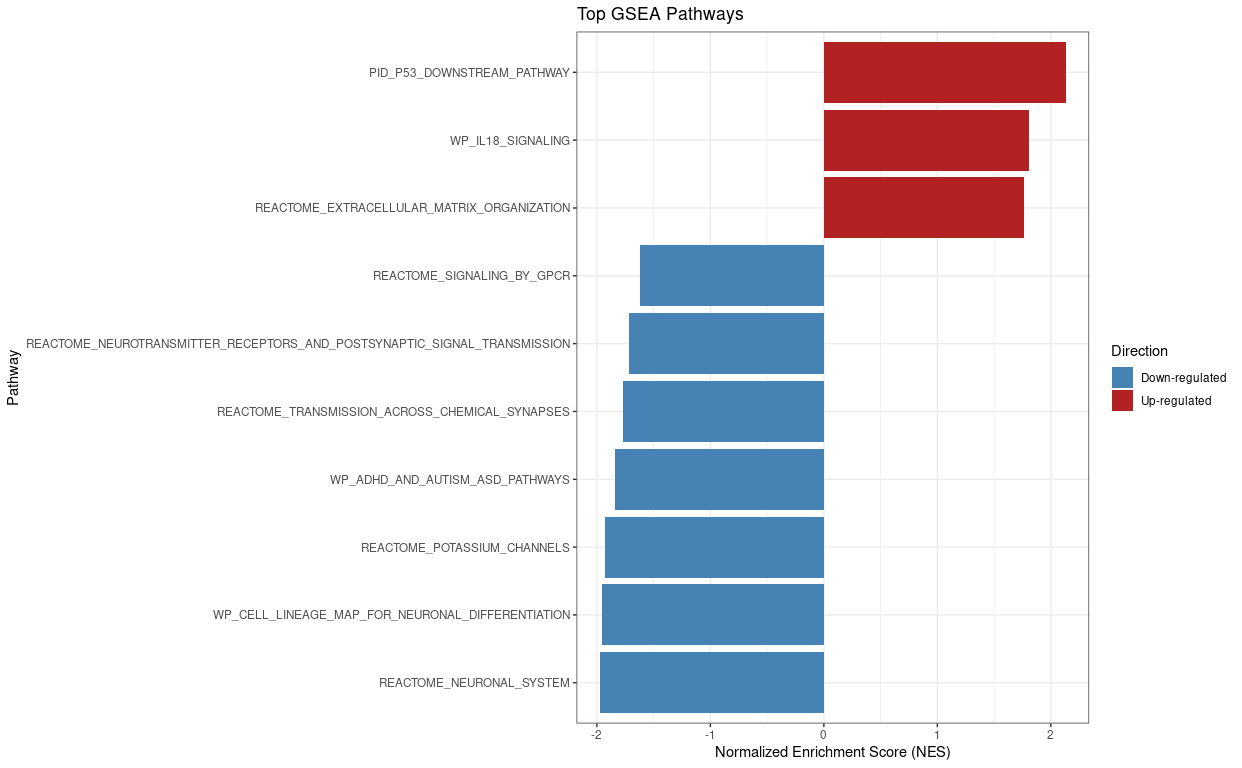
Figure 3. Gene Set Enrichment Analysis (GSEA) of TYK2 Knockout Transcriptome.

#### Comparisons of ENRICHR and GSEA
The complementary results from the enrichment (ENRICHR) and gene set enrichment (GSEA) analyses provide a cohesive and multi-faceted understanding of TYK2's role. Both ENRICHR and fgsea analyses highlight that TYK2 knockout at stage S5 could significantly affect cell death and extracellular matrix pathways while simultaneously suppressing neural and synaptic signaling. The overlap between these findings reinforces a possible mechanistic model in which the intervention triggers apoptosis and matrix remodeling while impairing neuronal and cell lineage pathways. Notably, GSEA revealed additional pathway-level trends (such as potassium channel and GPCR signaling) that may be missed by single-gene enrichment, emphasizing the value of transcriptome-wide ranking in uncovering broad biological themes. In conclusion, TYK2 acts as a critical master regulator during the endocrine precursor stage, where it is essential for activating the genetic programs that drive terminal endocrine differentiation while simultaneously influencing cell survival and niche interactions.
#### RNA-seq Quality Control
RNA-seq data quality was assessed through multiple approaches, including variance-stabilizing transformation (VST), principal component analysis (PCA), and a sample-to-sample distance matrix. The mean-SD plot following VST (Figure 4) demonstrates successful normalization. The plot shows a stable, low standard deviation across most genes with medium-to-high mean expression, confirming that variance has been effectively stabilized and is no longer dependent on the mean. As expected, a subset of low-count genes exhibits higher variability, which is a typical feature of RNA-seq data. This result validates that the normalization procedure was effective for downstream statistical analysis.
The PCA plot (Figure 5) shows a clear separation between control (WT) and experimental (TYK2 KO) samples along the first principal component (PC1) at 86% of the total variance. This indicates that the main source of variation in the dataset is attributable to the experimental treatment. The tight clustering of replicates within each group further supports the high reproducibility and low biological variability of RNA-seq data.
The sample-to-sample distance heat map (Figure 6) provides an overview of the similarity in gene expression profiles across all samples in the experiment. A clear separation between control and experiment groups are observed. Moreover, the high intra-group similarity and pronounced inter-group distance indicate that the TYK2 knockout induces consistent and robust transcriptomic changes, and technical or biological variation within each condition is relatively low. The heatmap also confirms that the major differences between WT and TYK2 KO genes were caused by treatment rather than random variability.

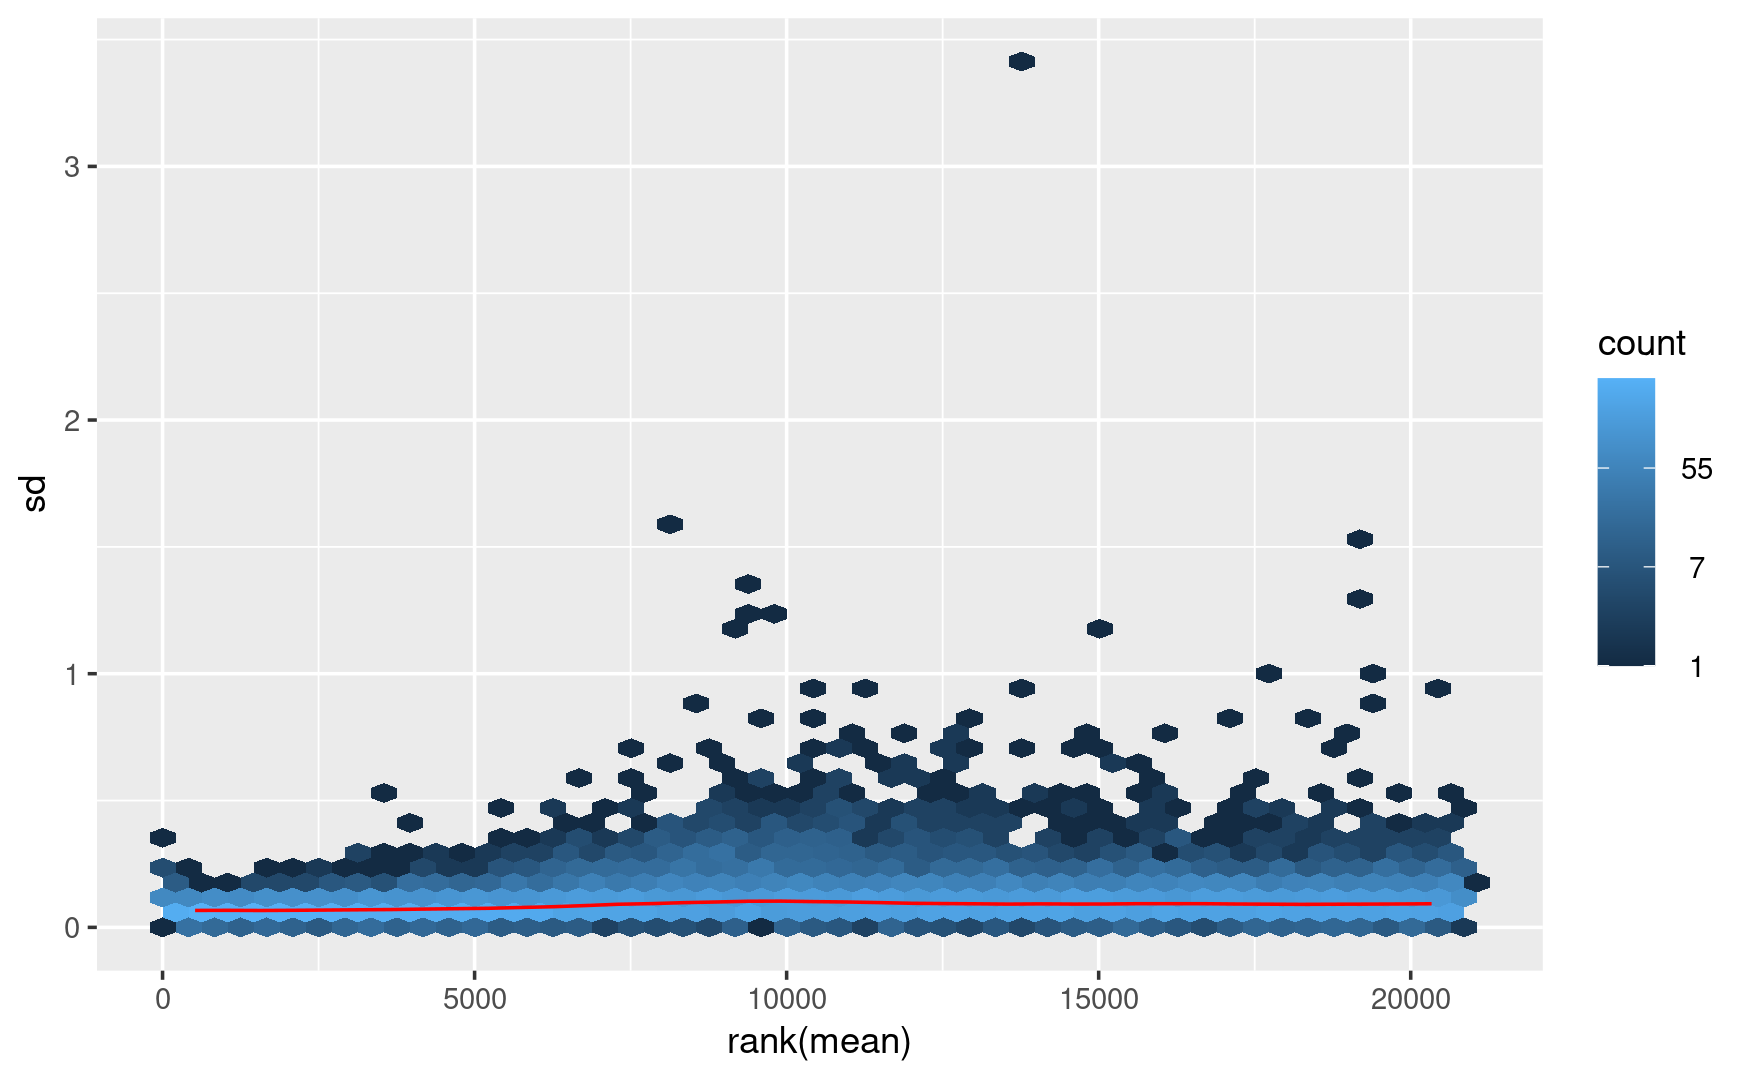
Figure 4. The mean-SD plot following variance-stabilizing transformation.
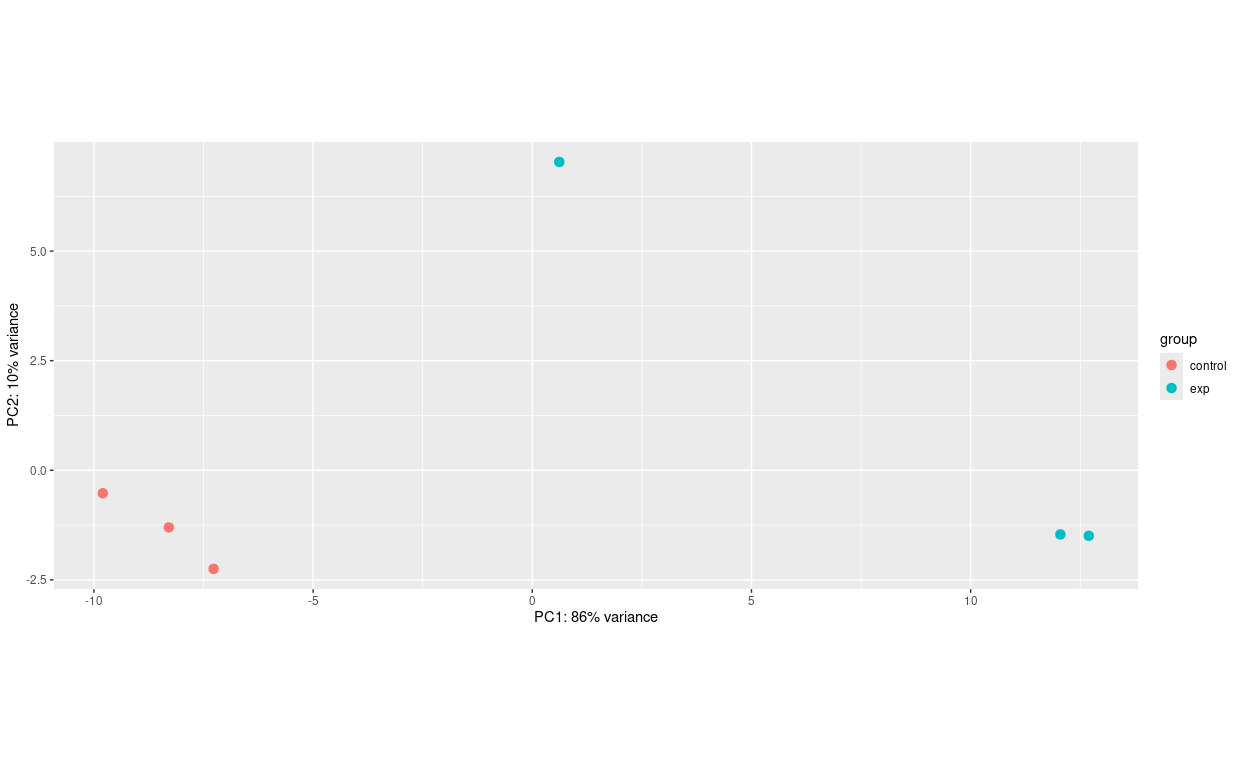
Figure 5. PCA on the normalized counts matrix: TYK2 KO cells: exp, WT: control.
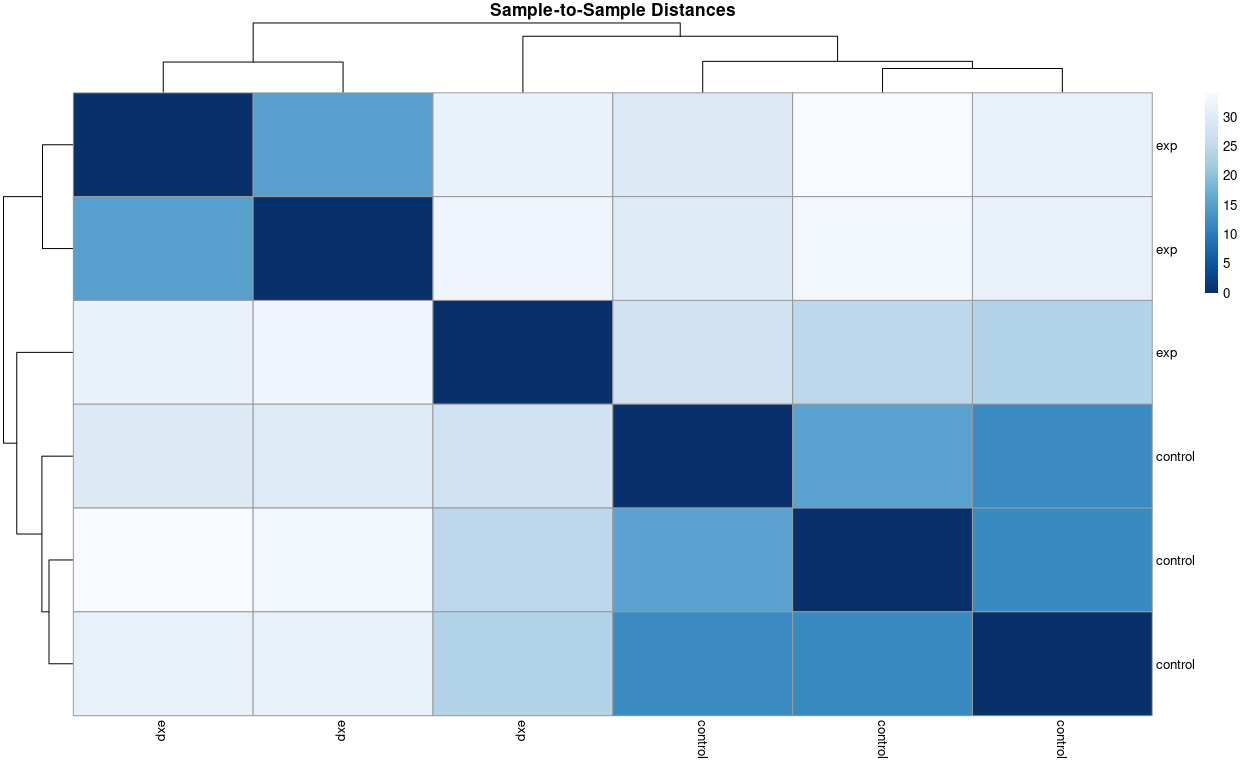
Figure 6. heatmap of the sample-to-sample distances for TYK2 KO (exp) and WT (control).

#### Replicate figure 3C and 3F
Both my volcano plot (Figure 7) and the plot from the paper display the distribution of genes based on expression difference (log2 fold change) and statistical significance at the S5 stage. In both plots, distinct sets of upregulated and downregulated genes are highlighted, with genes such as SPP1 and PAK3 appearing as significantly upregulated hits in both analyses. However, genes highlighted in the publication (KRAS, LAMB2, etc.) did not show up in my volcano plot. While my plot features a similar spread and magnitude of significance, some gene labeling differs, reflecting either minor variations in filtering thresholds or annotation practices. Reasons might contribute to the differences between paper’s plot and mine are discussed below. Overall, the concordance in the pattern and the major differentially expressed genes between the two plots suggests strong reproducibility of the experimental findings, supporting the validity of my analysis pipeline and results.
A comparison of the enrichment analysis results (Figure 8) reveals both shared and distinct findings between my dataset and the original publication. In my analysis, Reactome and MSigDB pathway enrichment highlighted upregulation in TP53-regulated cell death, extracellular matrix organization, and cytokine signaling, and distinct downregulation of neuronal differentiation and synaptic signaling pathways. These results provide a broad view of the transcriptomic changes induced by TYK2 knockout, emphasizing its critical regulation role in cell survival and neural processes. In contrast, the paper’s enrichment analyses were strongly focused on the receptor tyrosine kinase (RTK) and MAPK signaling pathways, particularly in relation to the regulation of KRAS expression by TYK2. Their Reactome results underscored a significant upregulation of RTK pathways specifically associated with cell cycle regulation and endocrine progenitor differentiation. This targeted interpretation aligns with the authors' discovery of the negative regulatory relationship between TYK2 and KRAS and its consequence for pancreatic endocrine cell maturation and diabetes risk. 
The differences between my pathway enrichment and the paper’s results are largely attributable to the choice of pathway databases, gene sets for enrichment, and the paper’s hypothesis-driven focus on endocrine differentiation mechanisms. My analysis employed a more exploratory approach, reflecting the overall biological processes affected by TYK2 knockout. Despite these distinctions, both analyses consistently point towards disrupted signaling and cell cycle pathways as central features of the KO phenotype.
Several factors could contribute to the observed differences between my plots and Figure 3C and Figure 3F in the publication. First, distinct computational pipelines for data processing were applied: my analysis utilized a Nextflow workflow with distinct modules for quality control, reads alignment, and expression quantification according to the instructions, which may have resulted in a subset of filtered reads and expressed genes that differs from the publication study. Second, even though the statistical threshold for significance (padj < 0.01) was consistent, the focus of the publication was on the mechanistic role of TYK2, particularly its negative regulation of KRAS and the downstream impact on pancreatic progenitor cell differentiation. The authors prioritized the biological interpretation of KRAS and associated pathways relevant to endocrine maturation and diabetes risk, whereas my analysis took a more agnostic, transcriptome-wide approach, without centering on any single gene or pathway. Lastly, the enrichment analyses were performed using different pathway and gene set databases, introducing further variability in the highlighted biological processes. The original research may have used specialized gene sets related specifically to TYK2 or β-cell biology, while my results depended on Reactome and MSigDB collections chosen for general pathway annotation. Taken together, these methodological, analytical, and biological priorities help explain both technical and interpretative differences in the volcano plots and the downstream findings.

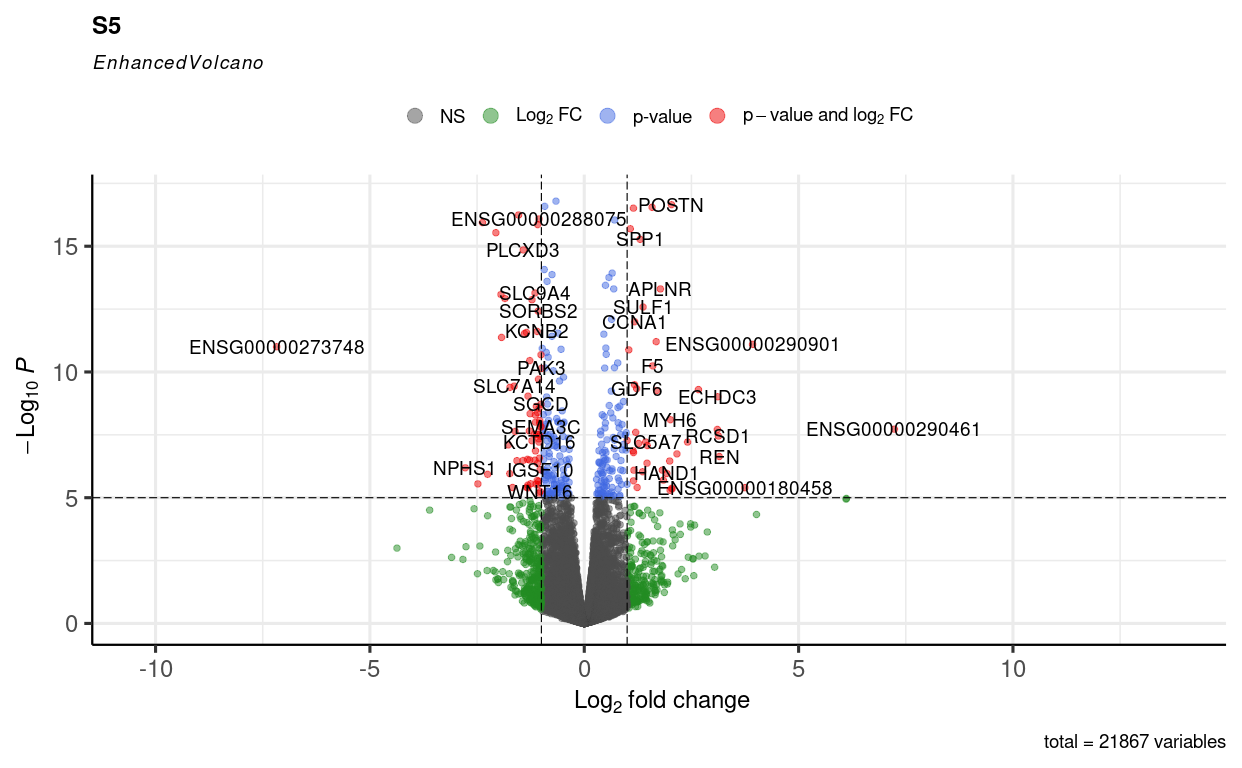
Figure 7. Volcano Plots of Differential Gene Expression in TYK2 Knockout at Stage S5. 
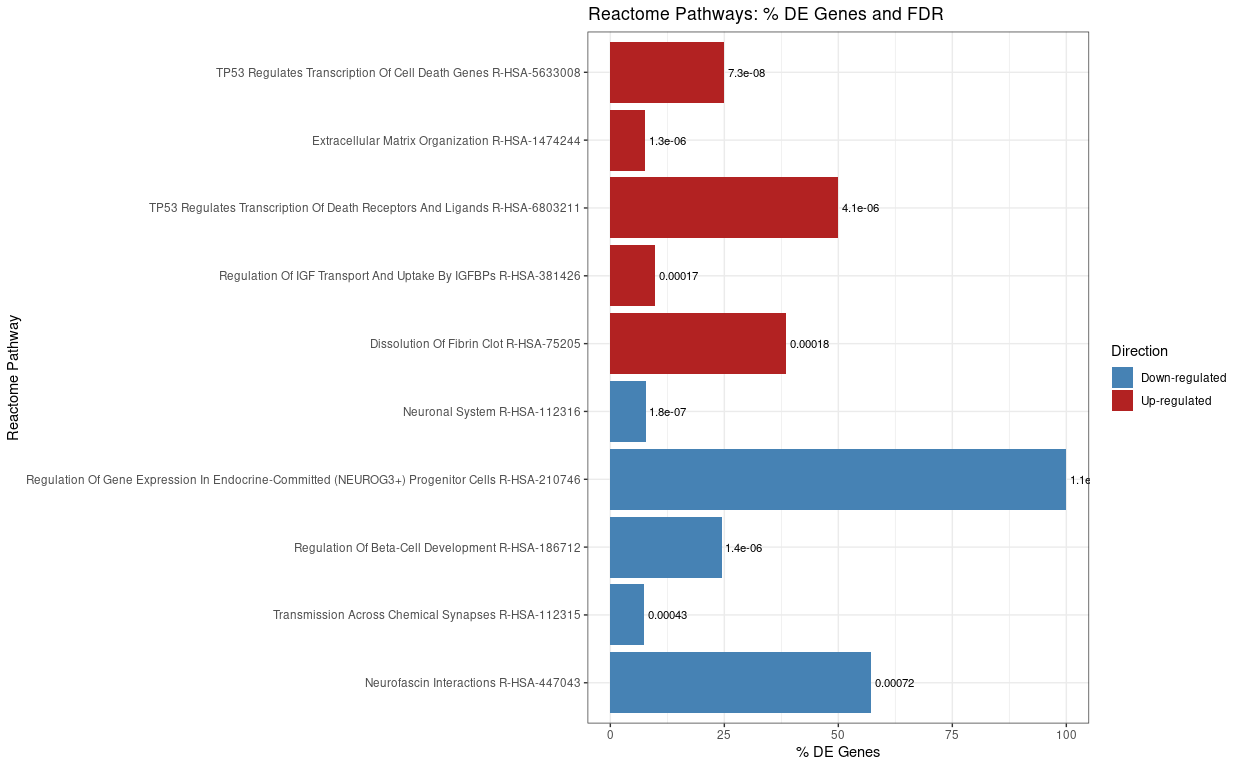
Figure 8. Up- and Down-Regulated Reactome Enrichment Pathways (Reactome Pathway 2022) in S5 KO Cells Compared to WT.

### References
(1)	Chandra, V.; Ibrahim, H.; Halliez, C.; Prasad, R. B.; Vecchio, F.; Dwivedi, O. P.; Kvist, J.; Balboa, D.; Saarimäki-Vire, J.; Montaser, H.; Barsby, T.; Lithovius, V.; Artner, I.; Gopalakrishnan, S.; Groop, L.; Mallone, R.; Eizirik, D. L.; Otonkoski, T. The Type 1 Diabetes Gene TYK2 Regulates β-Cell Development and Its Responses to Interferon-α. Nat. Commun. 2022, 13 (1), 6363. https://doi.org/10.1038/s41467-022-34069-z.

(2)	Di Tommaso, P.; Chatzou, M.; Floden, E. W.; Barja, P. P.; Palumbo, E.; Notredame, C. Nextflow Enables Reproducible Computational Workflows. Nat. Biotechnol. 2017, 35 (4), 316–319. https://doi.org/10.1038/nbt.3820.

(3)	Da Veiga Leprevost, F.; Grüning, B. A.; Alves Aflitos, S.; Röst, H. L.; Uszkoreit, J.; Barsnes, H.; Vaudel, M.; Moreno, P.; Gatto, L.; Weber, J.; Bai, M.; Jimenez, R. C.; Sachsenberg, T.; Pfeuffer, J.; Vera Alvarez, R.; Griss, J.; Nesvizhskii, A. I.; Perez-Riverol, Y. BioContainers: An Open-Source and Community-Driven Framework for Software Standardization. Bioinformatics 2017, 33 (16), 2580–2582. https://doi.org/10.1093/bioinformatics/btx192.

(4)	Ewels, P.; Magnusson, M.; Lundin, S.; Käller, M. MultiQC: Summarize Analysis Results for Multiple Tools and Samples in a Single Report. Bioinformatics 2016, 32 (19), 3047–3048. https://doi.org/10.1093/bioinformatics/btw354.

(5)	Dobin, A.; Davis, C. A.; Schlesinger, F.; Drenkow, J.; Zaleski, C.; Jha, S.; Batut, P.; Chaisson, M.; Gingeras, T. R. STAR: Ultrafast Universal RNA-Seq Aligner. Bioinformatics 2013, 29 (1), 15–21. https://doi.org/10.1093/bioinformatics/bts635.

(6)	Zhu, Q.; Fisher, S. A.; Shallcross, J.; Kim, J. VERSE: A Versatile and Efficient RNA-Seq Read Counting Tool. Bioinformatics May 14, 2016. https://doi.org/10.1101/053306.

(7)	Love, M. I.; Huber, W.; Anders, S. Moderated Estimation of Fold Change and Dispersion for RNA-Seq Data with DESeq2. Genome Biol. 2014, 15 (12), 550. https://doi.org/10.1186/s13059-014-0550-8.

(8)	Korotkevich, G.; Sukhov, V.; Budin, N.; Shpak, B.; Artyomov, M. N.; Sergushichev, A. Fast Gene Set Enrichment Analysis. Bioinformatics June 20, 2016. https://doi.org/10.1101/060012.

(9)	Subramanian, A.; Tamayo, P.; Mootha, V. K.; Mukherjee, S.; Ebert, B. L.; Gillette, M. A.; Paulovich, A.; Pomeroy, S. L.; Golub, T. R.; Lander, E. S.; Mesirov, J. P. Gene Set Enrichment Analysis: A Knowledge-Based Approach for Interpreting Genome-Wide Expression Profiles. Proc. Natl. Acad. Sci. 2005, 102 (43), 15545–15550. https://doi.org/10.1073/pnas.0506580102.

(10)	Chen, E. Y.; Tan, C. M.; Kou, Y.; Duan, Q.; Wang, Z.; Meirelles, G. V.; Clark, N. R.; Ma’ayan, A. Enrichr: Interactive and Collaborative HTML5 Gene List Enrichment Analysis Tool. BMC Bioinformatics 2013, 14 (1), 128. https://doi.org/10.1186/1471-2105-14-128.